$$M_{g}=| \frac{L_{n}f_{n}^2}{[(L_{n}+1)f_{n}^2-1]+j[(f_{n}^2-1)f_{n}Q_{e}L_{n}]}|$$

Good ti reference using the same controller: [ti reference](https://www.ti.com/lit/ug/sluuda3/sluuda3.pdf?ts=1784637627349&ref_url=https%253A%252F%252Fwww.ti.com%252Ftool%252FUCC25661EVM-128)

Design parameters:
- $V_{in_{min}} = 370V$
- $V_{in_{max}} = 430V$
- $V_{out_{min}} = 14V$
- $V_{out_{max}} = 24V$
- $P_{out}=150W$

# Plotting / analysis tools

In [17]:
import sympy as sp
import numpy as np
from scipy.optimize import root_scalar, brentq

import matplotlib.pyplot as plt
# plt.rcParams['figure.dpi'] = 150

import time
import random

def rand_color():
    return (random.random(), random.random(), random.random())

L_n = sp.symbols('L_n', real=True, positive=True)
f_n = sp.symbols('f_n', real=True, positive=True)
Q_e = sp.symbols('Q_e', real=True, positive=True)

m_g = (L_n*f_n**2) / (((L_n+1)*f_n**2 - 1) + sp.I*((f_n**2 - 1)*f_n*Q_e*L_n))

m_g_sqmag = sp.re(m_g)**2 + sp.im(m_g)**2
m_g_mag = sp.sqrt(m_g_sqmag)

m_g_mag_numeric = sp.lambdify([f_n, Q_e, L_n], m_g_mag, 'numpy')


# ** Plot Ln family **
def find_intersections(x_vals, y_vals, target, Q, L_test):
    """Finds intersection frequencies with horizontal line y=target."""
    intersections = []
    for i in range(len(x_vals)-1):
        if (y_vals[i]-target)*(y_vals[i+1]-target) <= 0:
            try:
                root = brentq(lambda f: m_g_mag_numeric(f, Q, L_test) - target,
                              x_vals[i], x_vals[i+1])
                intersections.append(root)
            except ValueError:
                pass
    return intersections

def plot_Ln_family(L_n, Q_e_values, f_n_range, show=True, **kwargs):
  for Q in Q_e_values:
    x_vals = np.linspace(*f_n_range, 1000)
    y_vals = m_g_mag_numeric(x_vals, Q, L_n=L_n)
    plt.plot(x_vals, y_vals, label=f"Q_e={Q:.2f} Ohm")

    # Process m_g_min and m_g_max
    for key in [('m_g_min'), ('m_g_max')]:
        if key in kwargs:
            target = kwargs[key]
            roots = find_intersections(x_vals, y_vals, target, Q, L_n)
            if not roots:
                print(f"Q={Q:.2f}, {key}={target}: no intersection "
                      f"(peak Mg below target -> gain unattainable at this Q, L_n)")
                continue
            f_intersection = np.max(roots)
            plt.axvline(f_intersection, linestyle='dotted', color=rand_color(), label=f"f_n={f_intersection:.2f}")
            print(f"Q={Q:.2f}, {key}={target}, f={f_intersection:.4f}")

  plt.xlabel('$f_{n}$')
  plt.ylabel('$M_{g}$')
  plt.ylim(0, 2)
  plt.xlim(1e-1, 10)
  plt.xscale('log')

  if 'm_g_min' in kwargs:
    m_g_min = kwargs['m_g_min']
    plt.hlines(m_g_min, f_n_range[0], f_n_range[1], colors=rand_color(), linestyles='dashed', label=f'Mg={m_g_min:.2f}')
  if 'm_g_max' in kwargs:
    m_g_max = kwargs['m_g_max']
    plt.hlines(m_g_max, f_n_range[0], f_n_range[1], colors=rand_color(), linestyles='dashed', label=f'Mg={m_g_max:.2f}')

  plt.legend(bbox_to_anchor=(1.01, 1.02), loc='upper left')
  plt.grid(True)

  if not show:
    return 

  plt.show()

# plot_Ln_family(L_n=5, Q_e_values=[0.1, 0.2, 0.5, 1, 2, 5, 10], f_n_range=(0.1, 10))


m_g_diff_symbolic = sp.diff(m_g_sqmag, f_n)

m_g_diff_numeric = sp.lambdify((f_n, Q_e, L_n), m_g_diff_symbolic, "numpy")


# ** Plot maximum attainable gain (Mg_ap) (independent of f_n) **
def plot_mg_ap(L_n_vals, Q_e_vals, m_g_max=None, **kwargs):
  t = time.time()

  def d_mg_df(f):
    return m_g_diff_numeric(f, Q_val, L_val)

  for L_val in L_n_vals:
      mg_ap = []
      for Q_val in Q_e_vals:
        try:
            sol = root_scalar(d_mg_df, bracket=[0.3, 1], method='brentq')
            if sol.converged:
                critical_f = sol.root
                mg_val = m_g_mag_numeric(critical_f, Q_val, L_val)
                mg_ap.append(mg_val)
            else:
                print("Root finding did not converge")
        except ValueError:
            print(f"No root found for L_n={L_val}, Q_e={Q_val}")
      plt.plot(Q_e_vals, mg_ap, label=f"L_n={L_val:.2f}")

  plt.title('Peak $M_{g}$ vs $Q_{e}$')
  plt.xlabel('$Q_{e}$')
  plt.ylabel('Peak $M_{g}$')
  if m_g_max:
    plt.ylim(1, m_g_max*1.5)
    plt.hlines(m_g_max, Q_e_vals[0], Q_e_vals[-1], colors='r', linestyles='dashed', label=f'Mg={m_g_max:.2f}')

  if 'Q_1' in kwargs:
    Q_1 = kwargs['Q_1']
    plt.vlines(Q_1, 0, m_g_max*1.5 if m_g_max else 2, colors='g', linestyles='dashed', label=f'Q_e={Q_1:.2f}')
  if 'Q_2' in kwargs:
    Q_2 = kwargs['Q_2']
    plt.vlines(Q_2, 0, m_g_max*1.5 if m_g_max else 2, colors='b', linestyles='dashed', label=f'Q_e={Q_2:.2f}')

  plt.legend(bbox_to_anchor=(1.01, 1.02), loc='upper left')
  plt.grid(True)

  plt.show()

  print("Time taken:", time.time() - t)

# L_n_vals = [1, 2, 5, 10]
# Q_e_vals = np.linspace(0.1, 1, 1000)

# plot_mg_ap(L_n_vals, Q_e_vals, m_g_max=2)

# Compute R_e, C_r, L_r, and f_0 based on  
# def get_circuit_params()

In [18]:
Vin_min = 380  # Minimum input voltage in volts
Vin_max = 420  # Maximum input voltage in volts
Vout_min = 20  # Minimum output voltage in volts
Vout_max = 22  # Maximum output voltage in volts
Pout_full = 150     # Output power in watts
Vin_nom = (Vin_min + Vin_max) / 2  # Nominal input voltage
Vout_nom = (Vout_min + Vout_max) / 2  # Nominal output voltage

η = 0.95 # Efficiency
P_in_full = Pout_full / η

Iout_full = Pout_full / Vout_nom  # Full output current in amps
print(f"Nominal output current Iout_full: {Iout_full} A")
Iin_full = P_in_full / (Vin_nom / 2)  # Full input current in amps
print(f"Nominal input current Iin_full: {Iin_full} A")

Pout_nom = 75 # Nominal output power in watts

n = (Vin_nom / 2) / Vout_nom  # Turns ratio
m_g_min = (n * Vout_min) / (Vin_max / 2)
m_g_max = (n * Vout_max) / (Vin_min / 2)
print(f"Turns ratio n: {n}")
print(f"Minimum voltage gain m_g_min: {m_g_min}")
print(f"Maximum voltage gain m_g_max: {m_g_max}")

Nominal output current Iout_full: 7.142857142857143 A
Nominal input current Iin_full: 0.7894736842105263 A
Turns ratio n: 9.523809523809524
Minimum voltage gain m_g_min: 0.9070294784580499
Maximum voltage gain m_g_max: 1.1027568922305764


In [19]:
# Rounding down n
n = int(n)
print(f"Rounded down turns ratio n: {n}")

# Assume an efficiency of 95%. Then P / 0.95 = P_in, and P_in * 5% = P_loss
P_loss = P_in_full * (1-η)
V_loss = P_loss / Iout_full

# Assume a forward voltage drop of 0.7V per diode
V_f = 0.7

m_g_min = n * (Vout_min + V_f) / (Vin_max / 2)
m_g_max = n * (Vout_max + V_f + V_loss) / (Vin_min / 2)

print(f"Minimum voltage gain m_g_min: {m_g_min}")
print(f"Maximum voltage gain m_g_max: {m_g_max}")

Rounded down turns ratio n: 9
Minimum voltage gain m_g_min: 0.887142857142857
Maximum voltage gain m_g_max: 1.1276177285318558


In [20]:
# Full load
R_e_full = (8 * n**2 / np.pi**2) * (Vout_nom / Iout_full)
print(f"Full load R_e: {R_e_full} Ohm")

# Half the load current
R_e_less = (8 * n**2 / np.pi**2) * (Vout_nom / (Iout_full * Pout_nom / Pout_full))
print(f"Half load R_e: {R_e_less} Ohm")

Full load R_e: 193.02901338069051 Ohm
Half load R_e: 386.058026761381 Ohm


Switching frequency f_0: 500.0 kHz
Resonant inductor L_r: 40.0 uH
Resonant capacitor C_r: 0.0025330295910584444 uF
Resonant impedance Z_r: 125.66370614359172 Ohm
Full load Q_e: 0.6510094205152394
Half load Q_e: 0.32550471025761973


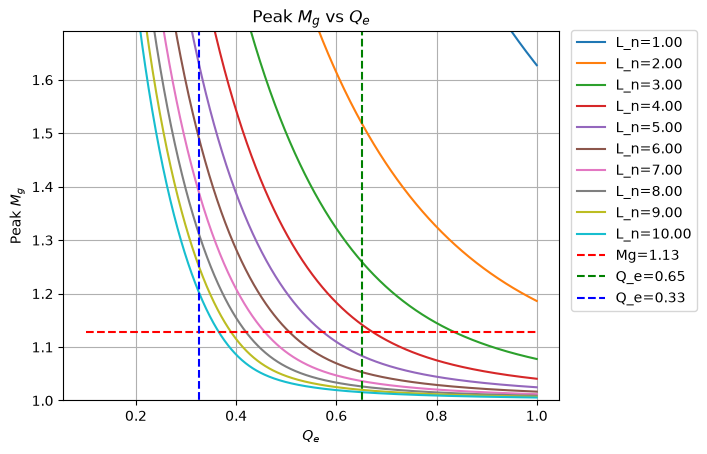

Time taken: 1.436164140701294


In [21]:
f_r = 500e3  # Resonant frequency in Hz
ω_r = 2 * np.pi * f_r  # Angular frequency in rad/s
L_r = 40e-6  # Resonant inductor in Henries
C_r = 1 / (ω_r**2 * L_r)  # Resonant capacitor in Farads
print(f"Switching frequency f_0: {f_r/1e3} kHz")
print(f"Resonant inductor L_r: {L_r*1e6} uH")
print(f"Resonant capacitor C_r: {C_r*1e6} uF")

Z_r = 2 * np.pi * f_r * L_r
print(f"Resonant impedance Z_r: {Z_r} Ohm")

Q_e_full = Z_r / R_e_full
Q_e_less = Z_r / R_e_less
print(f"Full load Q_e: {Q_e_full}")
print(f"Half load Q_e: {Q_e_less}")


L_n_vals = np.linspace(1, 10, 10)
Q_e_vals = np.linspace(0.1, 1, 1000)
plot_mg_ap(L_n_vals, Q_e_vals, m_g_max=m_g_max, Q_1=Q_e_full, Q_2=Q_e_less)

In general, when optimizing $L_n$ we would like to:
1. Choose it so that the gain curve is as flat as possible (easier controls because lower open loop gain)
2. Minimize the peak magnetizing current so the inductor is smaller
3. Be able to hit peak $M_g$ targets

Points 1-2 suggest that you should maximize $L_n$. To hit point 3, just need to have the peak $M_g$ always be higher than the max required - in this case, that makes $L_n=4$ the best option

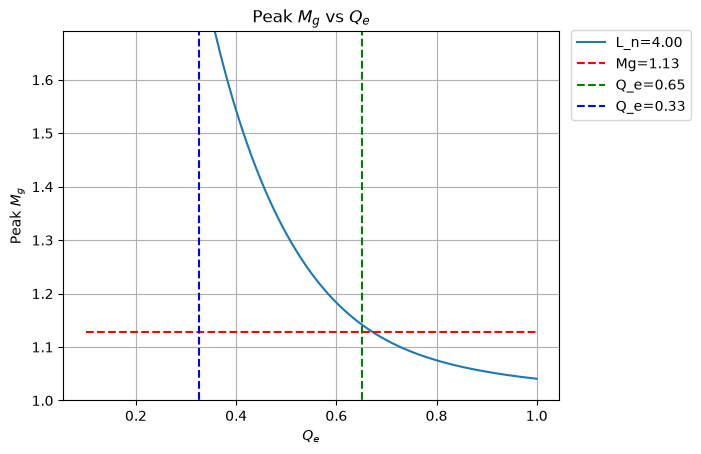

Time taken: 0.18347382545471191


In [22]:
L_n = 4
Q_e_vals = np.linspace(0.1, 1, 1000)

plot_mg_ap([L_n], Q_e_vals, m_g_max=m_g_max, Q_1=Q_e_full, Q_2=Q_e_less)

Q=0.65, m_g_min=0.887142857142857, f=1.2830
Q=0.65, m_g_max=1.1276177285318558: no intersection (peak Mg below target -> gain unattainable at this Q, L_n)
Q=0.33, m_g_min=0.887142857142857, f=1.4285
Q=0.33, m_g_max=1.1276177285318558, f=0.7805
Q=0.80, m_g_min=0.887142857142857, f=1.2441
Q=0.80, m_g_max=1.1276177285318558: no intersection (peak Mg below target -> gain unattainable at this Q, L_n)


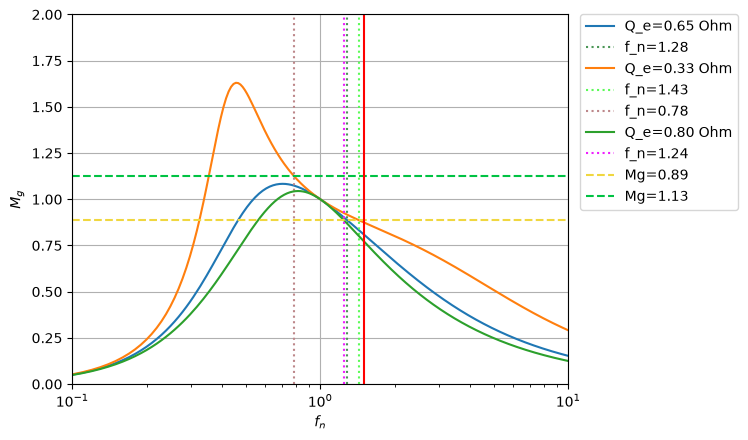

In [23]:
plot_Ln_family(L_n=5, Q_e_values=[Q_e_full, Q_e_less, 0.8], f_n_range=(0.1, 10), show=False, m_g_max=m_g_max, m_g_min=m_g_min)

controller_max_f = 750e3
plt.vlines(controller_max_f / f_r, 0, 2, colors='red')

In [24]:
L_m = L_n * L_r
print(f"Magnetizing inductance L_m: {L_m*1e6} uH")

Magnetizing inductance L_m: 160.0 uH


# Component sizing

In [25]:
Iout_full = Pout_full / Vout_min

Iload_equiv = np.pi * Iout_full / (2 * np.sqrt(2) * n)
I_mag = 0.901 * (n * Vout_max / (ω_r * L_m))

I_rms = np.sqrt(Iload_equiv**2 + I_mag**2)

print(f"Maximum primary side current: {I_rms}")


Maximum primary side current: 0.9913116045783487


### Output Power
$$
V_{\text{out}} \;=\; 
\frac{j \omega L_{m}\parallel R_e}{\,j \omega L_{m}\parallel R_e \;+\; j \,\omega_0 \bigl(C_r + L_r \bigr)} 
\;\cdot\; \frac{2 V_{\text{in,nom}}}{\pi}
$$

$$

P_{out} = \frac{V_{out}^2}{R_{e}}

$$

                       254.647908947033⋅Lₘ⋅Rₑ                       
────────────────────────────────────────────────────────────────────
Lₘ⋅Rₑ + 3141592.65358979⋅ⅈ⋅(Cᵣ + Lᵣ)⋅(Lₘ - 3.18309886183791e-7⋅ⅈ⋅Rₑ)
Calculated theoretical full load output power: 169.11787191189788 W, 160.66197831630296 with 95.0% efficiency
Calculated theoretical less load output power: 100.66993480698852 W, 95.63643806663909 with 95.0% efficiency
Series resonance impedance: 0.0


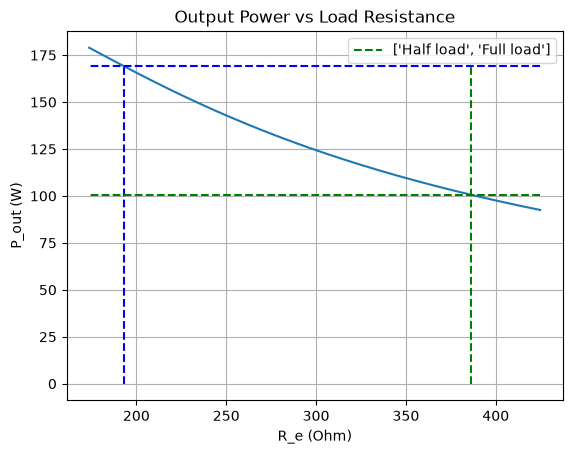

In [26]:
# Lets figure out output power

def par_Z(Z1, Z2):
  return 1 / (1/Z1 + 1/Z2)

C_r_symbolic, L_r_symbolic, R_e_symbolic, L_m_symbolic = sp.symbols('C_r L_r R_e L_m', real=True, positive=True)
L_m_par_R_e = par_Z(1j * ω_r * L_m_symbolic, R_e_symbolic)

V_out = (L_m_par_R_e / (L_m_par_R_e + 1j * ω_r * (C_r_symbolic + L_r_symbolic))) * (2 * (Vin_nom / np.pi))
V_out = sp.simplify(V_out)
sp.pretty_print(V_out)

P_out = sp.simplify((sp.Abs(V_out)**2) / R_e_symbolic)

P_out_numeric = sp.lambdify((C_r_symbolic, L_r_symbolic, R_e_symbolic, L_m_symbolic), P_out, 'numpy')
Pout_full_calc = P_out_numeric(C_r, L_r, R_e_full, L_m)
Pout_less_calc = P_out_numeric(C_r, L_r, R_e_less, L_m)
print(f"Calculated theoretical full load output power: {Pout_full_calc} W, {Pout_full_calc * η} with {η*100}% efficiency")
print(f"Calculated theoretical less load output power: {Pout_less_calc} W, {Pout_less_calc * η} with {η*100}% efficiency")

print(f"Series resonance impedance: {np.abs(1j * ω_r * L_r + 1/(1j * ω_r * C_r))}")

R_e_range = np.linspace(R_e_less * 1.1, R_e_full * 0.9, 1000)
P_out_range = P_out_numeric(C_r, L_r, R_e_range, L_m)
plt.plot(R_e_range, P_out_range)
plt.vlines([R_e_less, R_e_full], 0, Pout_full_calc, colors=['g', 'b'], linestyles='dashed', label=['Half load', 'Full load'])
plt.hlines([Pout_less_calc, Pout_full_calc], R_e_range[0], R_e_range[-1], colors=['g', 'b'], linestyles='dashed')
plt.xlabel('R_e (Ohm)')
plt.ylabel('P_out (W)')
plt.title('Output Power vs Load Resistance')
plt.grid(True)
plt.legend()
plt.show()

# Bode plot experiments, not that interesting

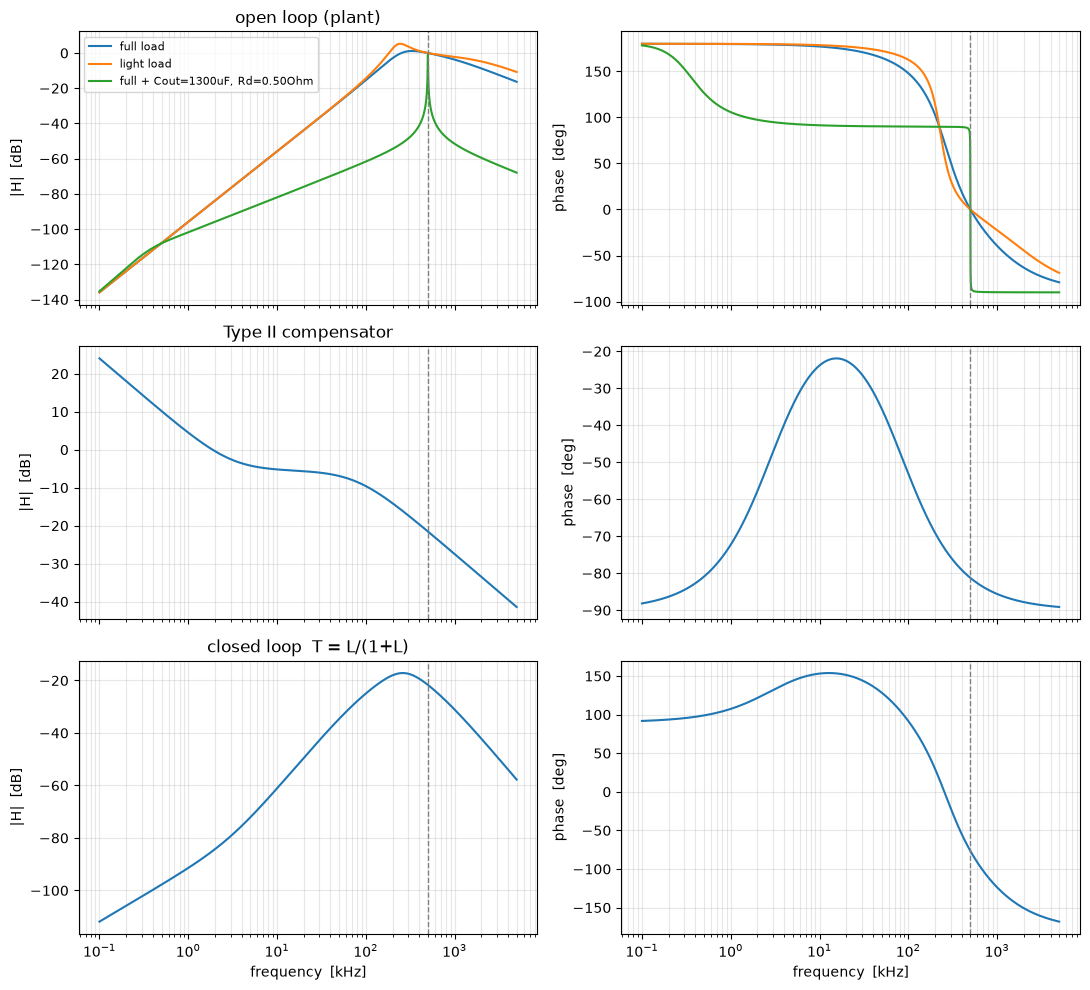

In [27]:
# Open-loop plant, Type II compensator, and closed loop -- Bode stack
# --- place these ---
f_z, f_p, K = 3e3, 80e3, 1e4     # Type II zero, pole, gain
C_out = 1300e-6                    # output cap across the load (AC-equivalent) [F]
R_d   = 0.5                     # series damping R (ESR) with the cap [Ohm] -> zero at 1/(2*pi*R_d*C_out)

w_z, w_p = 2*np.pi*f_z, 2*np.pi*f_p

def plant(f, R, Cout=0.0, Rd=0.0):   # tank gain, load = R || (Rd + 1/jwC)
    w = 2*np.pi*f
    Zs = 1j*w*L_r + 1/(1j*w*C_r)
    Yc = 1/(Rd + 1/(1j*w*Cout)) if Cout > 0 else 0
    Zload = 1 / (1/R + Yc)
    Zp = 1 / (1/(1j*w*L_m) + 1/Zload)
    return Zp / (Zs + Zp)

def Gc(f):                       # Type II: integrator + zero + pole
    s = 1j*2*np.pi*f
    return K * (1 + s/w_z) / (s * (1 + s/w_p))

f = np.logspace(2, np.log10(f_r) + 1, 3000)   # 100 Hz .. 10*f_r

P_full  = plant(f, R_e_full)
P_light = plant(f, R_e_less)
P_cap   = plant(f, R_e_full, C_out, R_d)
comp    = Gc(f)
L_open  = P_full * comp          # loop gain
T_cl    = L_open / (1 + L_open)  # closed loop

fig, ax = plt.subplots(3, 2, figsize=(11, 10), sharex=True)
def bode(row, H, **kw):
    ax[row, 0].semilogx(f/1e3, 20*np.log10(np.abs(H)), **kw)
    ax[row, 1].semilogx(f/1e3, np.degrees(np.angle(H)), **kw)

bode(0, P_full,  label='full load')
bode(0, P_light, label='light load')
bode(0, P_cap,   label=f'full + Cout={C_out*1e6:.0f}uF, Rd={R_d:.2f}Ohm')
bode(1, comp)
bode(2, T_cl)

titles = ['open loop (plant)', 'Type II compensator', 'closed loop  T = L/(1+L)']
for r, t in enumerate(titles):
    ax[r, 0].set_ylabel('|H|  [dB]'); ax[r, 0].set_title(t)
    ax[r, 1].set_ylabel('phase  [deg]')
    for cc in (0, 1):
        ax[r, cc].grid(True, which='both', alpha=0.3)
        ax[r, cc].axvline(f_r/1e3, ls='--', c='gray', lw=1)
ax[0, 0].legend(fontsize=8)
ax[2, 0].set_xlabel('frequency  [kHz]'); ax[2, 1].set_xlabel('frequency  [kHz]')
plt.tight_layout()
plt.show()
